In [102]:
!pip install seaborn
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 5.6 MB/s eta 0:00:19
    --------------------------------------- 1.6/101.7 MB 4.4 MB/s eta 0:00:23
    --------------------------------------- 2.4/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 3.1/101.7 MB 4.1 MB/s eta 0:00:25
   - -------------------------------------- 4.2/101.7 MB 4.2 MB/s eta 0:00:24
   -- ------------------------------------- 5.5/101.7 MB 4.5 MB/s eta 0:00:22
   -- ------------------------------------- 6.6/101.7 MB 4.6 MB/s eta 0:00:21
   -- ------------------------------------- 7.6/101.7 MB 4.6 MB/s eta 0:00:21
   --- ------------------------------------ 8.4/101.7 MB 4.6 MB/s eta 0:00:21
   --- ------------------------------------ 9.7/101.7 MB 4.7 MB/s eta 0:00:20
   ---- ----------------------------------- 10.7/101.7 MB 4.8 MB/s eta 0:00:20
   ---- ----------------------------------- 11.8/101.7 MB 4.8 MB/s eta

In [57]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [12]:
df = pd.read_excel(r"C:\Users\kokki\Downloads\hr.xlsx")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Attrition                   1470 non-null   object
 1   Business Travel             1470 non-null   object
 2   CF_age band                 1470 non-null   object
 3   CF_attrition label          1470 non-null   object
 4   Department                  1470 non-null   object
 5   Education Field             1470 non-null   object
 6   emp no                      1470 non-null   object
 7   Employee Number             1470 non-null   int64 
 8   Gender                      1470 non-null   object
 9   Job Role                    1470 non-null   object
 10  Marital Status              1470 non-null   object
 11  Over Time                   1470 non-null   object
 12  Over18                      1470 non-null   object
 13  Training Times Last Year    1470 non-null   int6

In [26]:
df.isna().sum()

Attrition                     0
Business Travel               0
CF_age band                   0
CF_attrition label            0
Department                    0
Education Field               0
emp no                        0
Employee Number               0
Gender                        0
Job Role                      0
Marital Status                0
Over Time                     0
Over18                        0
Training Times Last Year      0
-2                            0
0                             0
Age                           0
CF_current Employee           0
Daily Rate                    0
Distance From Home            0
Education                     0
Employee Count                0
Environment Satisfaction      0
Hourly Rate                   0
Job Involvement               0
Job Level                     0
Job Satisfaction              0
Monthly Income                0
Monthly Rate                  0
Num Companies Worked          0
Percent Salary Hike           0
Performa

In [27]:
df.duplicated().sum()

0

In [28]:
df.describe()

,Employee Number,Training Times Last Year,-2,0,Age,CF_current Employee,Daily Rate,Distance From Home,Employee Count,Environment Satisfaction,...,Performance Rating,Relationship Satisfaction,Standard Hours,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
count,1470.000000,1470.000000,1470.0,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,...,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,1024.865306,2.799320,-2.0,0.0,36.923810,0.838776,802.485714,9.192517,1.0,2.721769,...,3.153741,2.712245,80.0,0.793878,11.279592,2.761224,7.008163,4.229252,2.187755,4.123129
std,602.024335,1.289271,0.0,0.0,9.135373,0.367863,403.509100,8.106864,0.0,1.093082,...,0.360824,1.081209,0.0,0.852077,7.780782,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,0.000000,-2.0,0.0,18.000000,0.000000,102.000000,1.000000,1.0,1.000000,...,3.000000,1.000000,80.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,491.250000,2.000000,-2.0,0.0,30.000000,1.000000,465.000000,2.000000,1.0,2.000000,...,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,1020.500000,3.000000,-2.0,0.0,36.000000,1.000000,802.000000,7.000000,1.0,3.000000,...,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1555.750000,3.000000,-2.0,0.0,43.000000,1.000000,1157.000000,14.000000,1.0,4.000000,...,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,2068.000000,6.000000,-2.0,0.0,60.000000,1.000000,1499.000000,29.000000,1.0,4.000000,...,4.000000,4.000000,80.0,3.000000,40.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [29]:
df.columns.tolist()

['Attrition',
 'Business Travel',
 'CF_age band',
 'CF_attrition label',
 'Department',
 'Education Field',
 'emp no',
 'Employee Number',
 'Gender',
 'Job Role',
 'Marital Status',
 'Over Time',
 'Over18',
 'Training Times Last Year',
 '-2',
 '0',
 'Age',
 'CF_current Employee',
 'Daily Rate',
 'Distance From Home',
 'Education',
 'Employee Count',
 'Environment Satisfaction',
 'Hourly Rate',
 'Job Involvement',
 'Job Level',
 'Job Satisfaction',
 'Monthly Income',
 'Monthly Rate',
 'Num Companies Worked',
 'Percent Salary Hike',
 'Performance Rating',
 'Relationship Satisfaction',
 'Standard Hours',
 'Stock Option Level',
 'Total Working Years',
 'Work Life Balance',
 'Years At Company',
 'Years In Current Role',
 'Years Since Last Promotion',
 'Years With Curr Manager']

In [30]:
number_of_employees = df['Employee Count'].sum()
print("number of employees:", number_of_employees)

number of employees: 1470


In [31]:
number=df['Attrition'].value_counts()["Yes"]
print("Attribution:",number)

Attribution: 237


In [32]:
attri_percentage = df['Attrition'].value_counts()["Yes"]*100/len(df)
print("Total percentage of attrition in company:", attri_percentage)


Total percentage of attrition in company: 16.122448979591837


In [33]:
active_employee =df['Attrition'].value_counts()["No"]
print("active employee ",active_employee)

active employee  1233


In [34]:
average_age = df["Age"].median()
print("The average age:",average_age)

The average age: 36.0


C:\Users\kokki\AppData\Local\Temp\ipykernel_27272\1330148113.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender = df.groupby(['age_group', 'Gender']).size().unstack(fill_value=0)


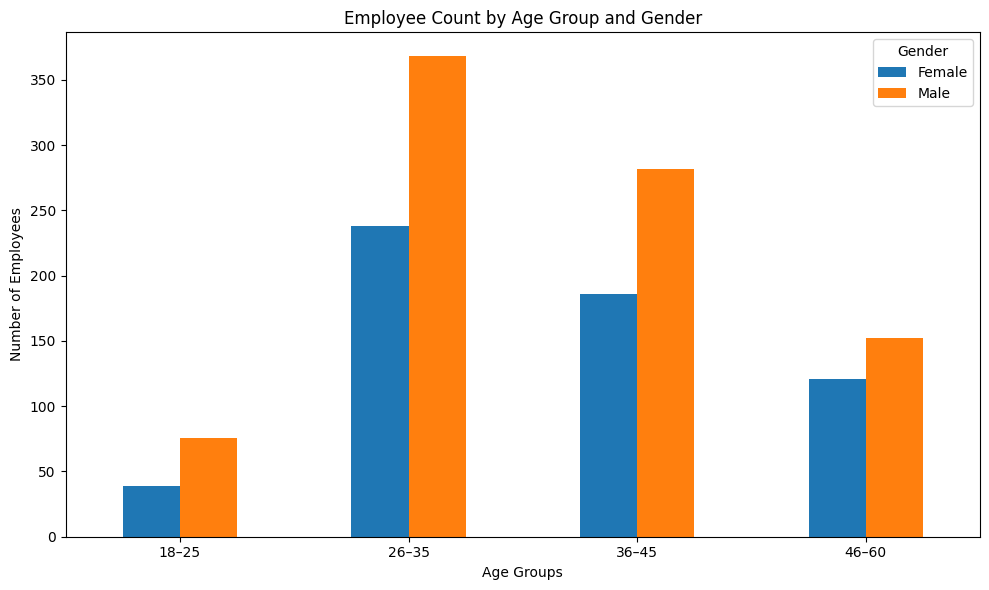

In [35]:
bins = [18, 25, 35, 45, 60]
labels = ['18–25', '26–35', '36–45', '46–60']

# Create age groups
df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

# Count employees by age group and gender
age_gender = df.groupby(['age_group', 'Gender']).size().unstack(fill_value=0)

# Plot grouped bar chart
age_gender.plot(kind='bar', figsize=(10,6))

plt.xlabel("Age Groups")
plt.ylabel("Number of Employees")
plt.title("Employee Count by Age Group and Gender")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
dept_counts = df.groupby(['Department', 'Attrition']).size()

In [37]:
dept_pivot = dept_counts.unstack(fill_value=0)

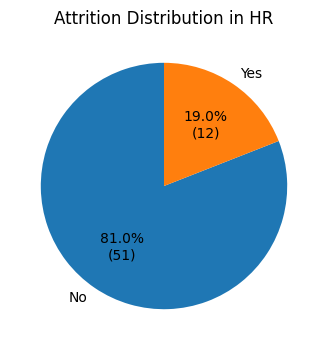

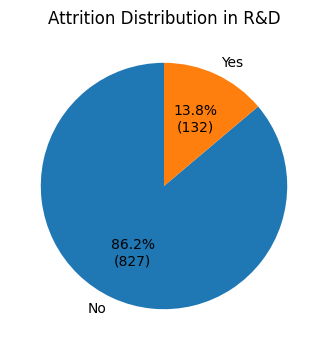

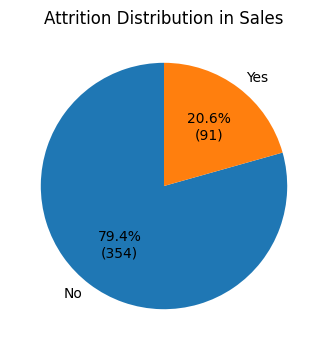

In [38]:
for dept in dept_pivot.index:
    values = dept_pivot.loc[dept]

    plt.figure(figsize=(6,4))
    plt.pie(
        values,
        labels=values.index,
        autopct=lambda p: f'{p:.1f}%\n({int(p*values.sum()/100)})',
        startangle=90
    )
    plt.title(f"Attrition Distribution in {dept}")
    plt.show()

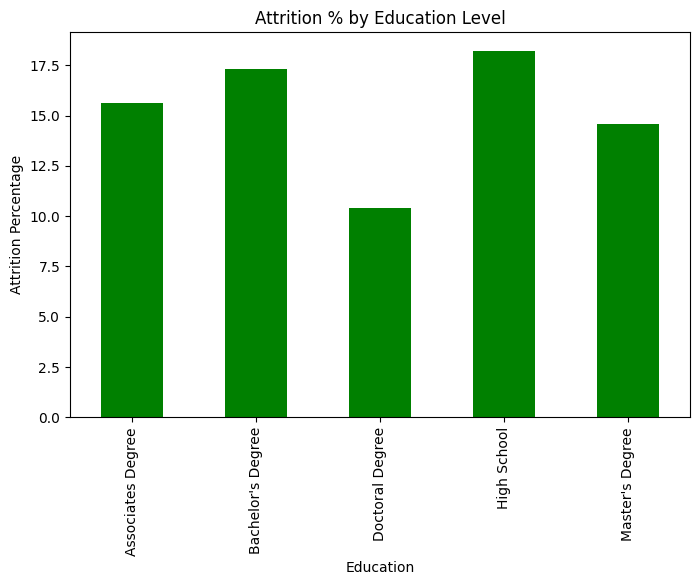

In [39]:
# Standardize Attrition values
df['Attrition'] = df['Attrition'].str.strip().str.title()

# Group by Education and Attrition
att_education = (
    df.groupby(['Education', 'Attrition'])
      .size()
      .unstack(fill_value=0)
)

# Ensure missing Yes/No columns exist
for col in ['Yes', 'No']:
    if col not in att_education.columns:
        att_education[col] = 0

# Calculate attrition %
att_education['Attrition_%'] = (
    att_education['Yes'] * 100 / att_education.sum(axis=1)
)

# Plot
att_education['Attrition_%'].plot(
    kind="bar",
    figsize=(8,5),
    color="green"
)

plt.ylabel("Attrition Percentage")
plt.title("Attrition % by Education Level")
plt.show()

In [40]:
# Under_25

In [ ]:
attri_25=df.groupby()

In [44]:
df.columns

Index(['Attrition', 'Business Travel', 'CF_age band', 'CF_attrition label',
       'Department', 'Education Field', 'emp no', 'Employee Number', 'Gender',
       'Job Role', 'Marital Status', 'Over Time', 'Over18',
       'Training Times Last Year', '-2', '0', 'Age', 'CF_current Employee',
       'Daily Rate', 'Distance From Home', 'Education', 'Employee Count',
       'Environment Satisfaction', 'Hourly Rate', 'Job Involvement',
       'Job Level', 'Job Satisfaction', 'Monthly Income', 'Monthly Rate',
       'Num Companies Worked', 'Percent Salary Hike', 'Performance Rating',
       'Relationship Satisfaction', 'Standard Hours', 'Stock Option Level',
       'Total Working Years', 'Work Life Balance', 'Years At Company',
       'Years In Current Role', 'Years Since Last Promotion',
       'Years With Curr Manager', 'age_group'],
      dtype='object')

<Axes: xlabel='Job Level', ylabel='count'>

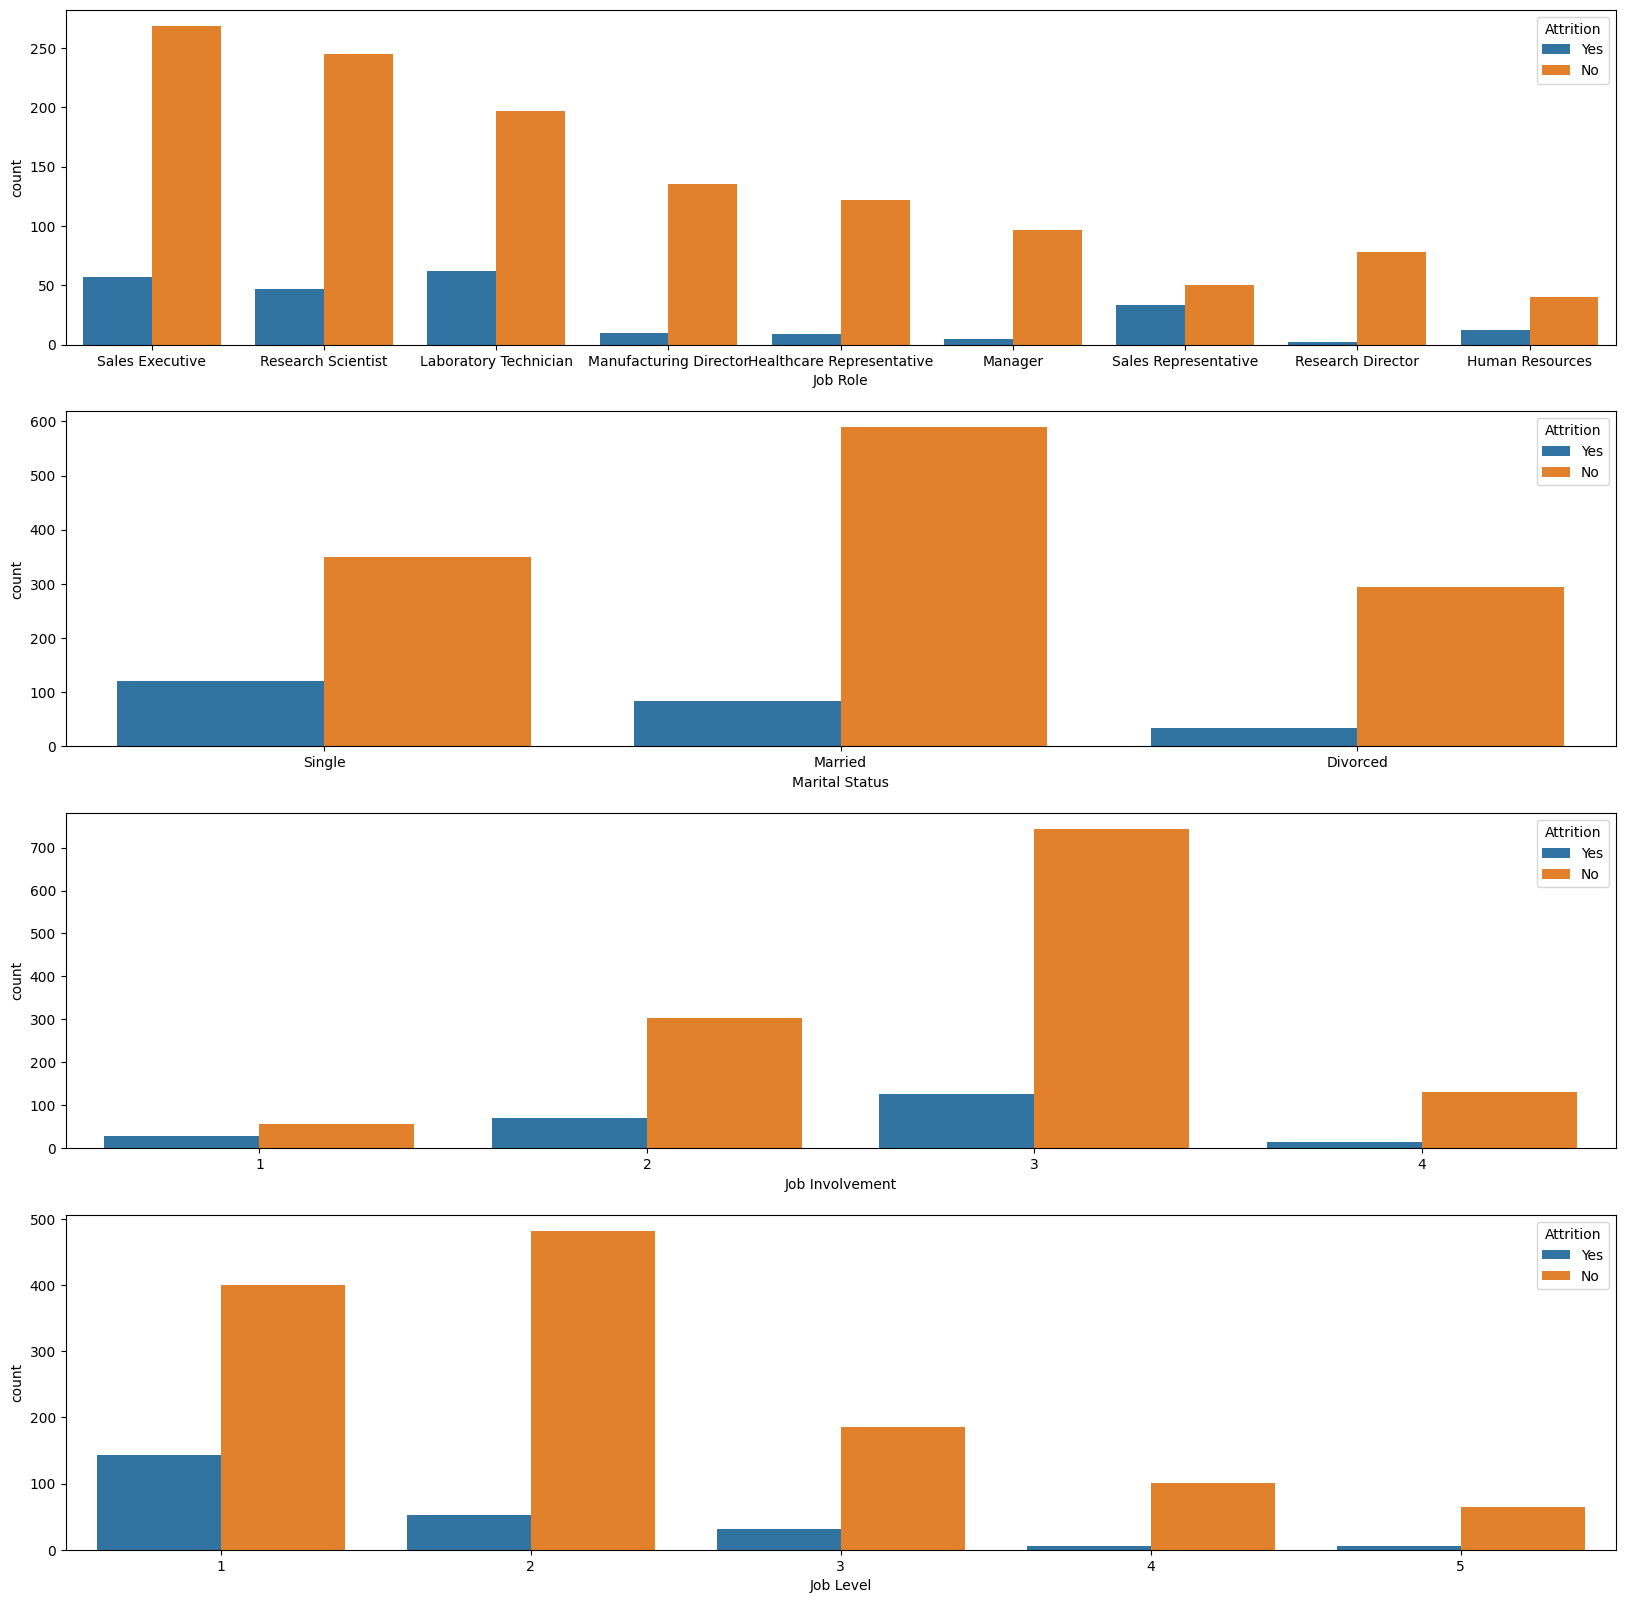

In [31]:
plt.figure(figsize=[20,20])
plt.subplot(411)
sns.countplot(x='Job Role', hue='Attrition', data= df)

plt.subplot(412)
sns.countplot(x='Marital Status', hue='Attrition', data= df)

plt.subplot(413)
sns.countplot(x='Job Involvement', hue='Attrition', data= df)

plt.subplot(414)
sns.countplot(x='Job Level', hue='Attrition', data= df)

<Axes: xlabel='Monthly Income', ylabel='Job Role'>

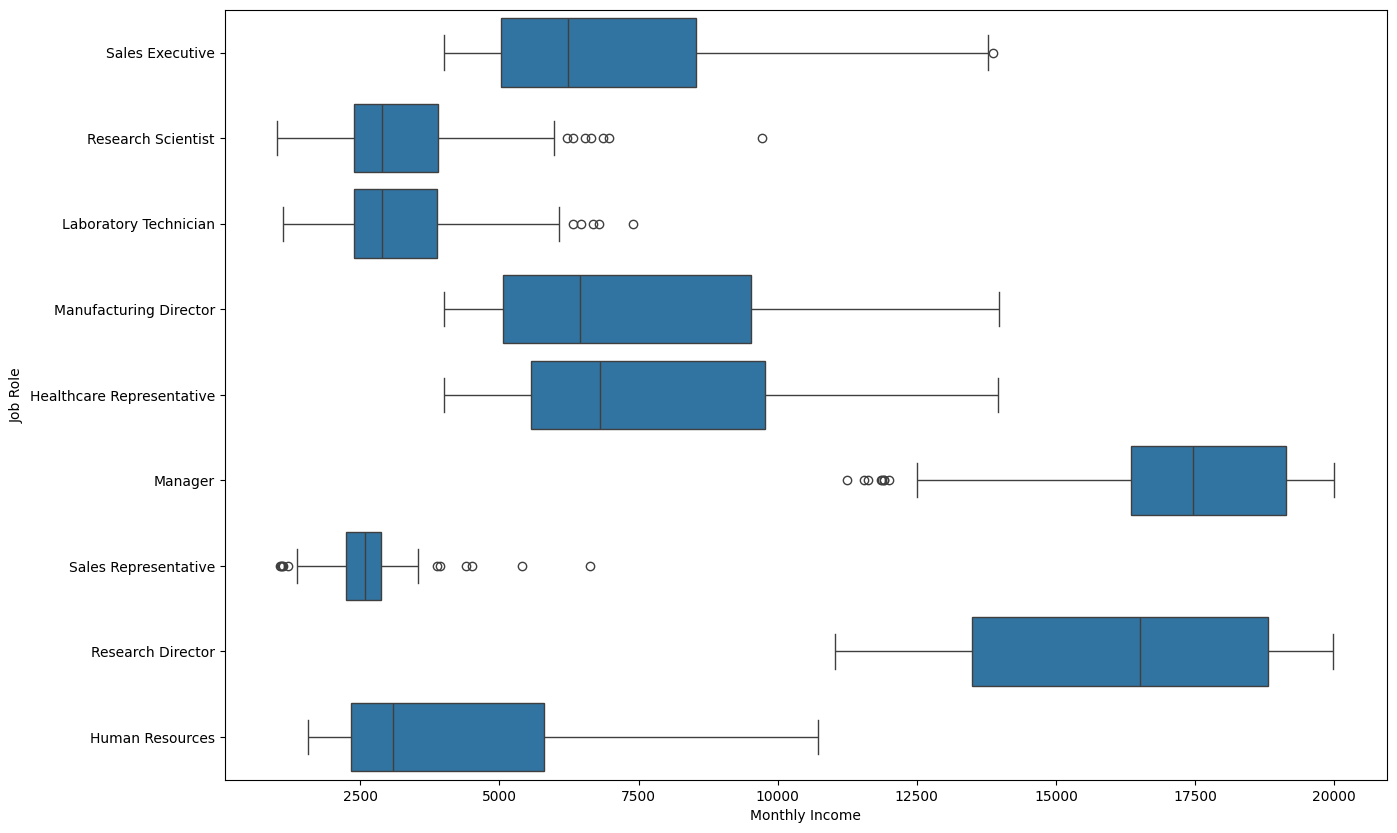

In [32]:
plt.figure(figsize=(15, 10))
sns.boxplot(x='Monthly Income', y='Job Role', data= df)

In [49]:
left_df = df[df['Attrition'] == 'Yes']
stayed_df = df[df['Attrition'] == 'No']

In [50]:
left_df

,Attrition,Business Travel,CF_age band,CF_attrition label,Department,Education Field,emp no,Employee Number,Gender,Job Role,...,Performance Rating,Relationship Satisfaction,Standard Hours,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
0,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,STAFF-1,1,Female,Sales Executive,...,3,1,80,0,8,1,6,4,0,5
2,Yes,Travel_Rarely,35 - 44,Ex-Employees,R&D,Other,STAFF-4,4,Male,Laboratory Technician,...,3,2,80,0,7,3,0,0,0,0
14,Yes,Travel_Rarely,25 - 34,Ex-Employees,R&D,Life Sciences,STAFF-19,19,Male,Laboratory Technician,...,3,2,80,0,6,3,4,2,0,3
21,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,STAFF-27,27,Male,Sales Representative,...,4,2,80,0,10,3,5,3,0,3
24,Yes,Travel_Rarely,25 - 34,Ex-Employees,R&D,Medical,STAFF-31,31,Male,Research Scientist,...,3,3,80,0,8,3,4,2,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,Yes,Non-Travel,25 - 34,Ex-Employees,R&D,Technical Degree,STAFF-1905,1905,Male,Research Scientist,...,4,2,80,1,5,3,5,2,3,0
1466,Yes,Travel_Frequently,25 - 34,Ex-Employees,R&D,Life Sciences,STAFF-1868,1868,Male,Research Scientist,...,4,2,80,0,1,2,1,0,1,0
1467,Yes,Travel_Frequently,35 - 44,Ex-Employees,Sales,Other,STAFF-1667,1667,Male,Sales Executive,...,4,1,80,0,13,4,11,9,6,7
1468,Yes,Travel_Rarely,Under 25,Ex-Employees,R&D,Life Sciences,STAFF-1878,1878,Male,Research Scientist,...,4,1,80,0,1,3,1,0,0,0


In [52]:
stayed_df

,Attrition,Business Travel,CF_age band,CF_attrition label,Department,Education Field,emp no,Employee Number,Gender,Job Role,...,Performance Rating,Relationship Satisfaction,Standard Hours,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
1,No,Travel_Frequently,45 - 54,Current Employees,R&D,Life Sciences,STAFF-2,2,Male,Research Scientist,...,4,4,80,1,10,3,10,7,1,7
3,No,Travel_Frequently,25 - 34,Current Employees,R&D,Life Sciences,STAFF-5,5,Female,Research Scientist,...,3,3,80,0,8,3,8,7,3,0
4,No,Travel_Rarely,25 - 34,Current Employees,R&D,Medical,STAFF-7,7,Male,Laboratory Technician,...,3,4,80,1,6,3,2,2,2,2
5,No,Travel_Frequently,25 - 34,Current Employees,R&D,Life Sciences,STAFF-8,8,Male,Laboratory Technician,...,3,3,80,0,8,2,7,7,3,6
6,No,Travel_Rarely,Over 55,Current Employees,R&D,Medical,STAFF-10,10,Female,Laboratory Technician,...,4,1,80,3,12,2,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1395,No,Travel_Rarely,35 - 44,Current Employees,HR,Medical,STAFF-1550,1550,Male,Manager,...,4,4,80,0,21,3,21,7,7,7
1396,No,Travel_Rarely,25 - 34,Current Employees,R&D,Life Sciences,STAFF-2064,2064,Male,Manufacturing Director,...,4,2,80,1,6,3,6,2,0,3
1397,No,Travel_Rarely,35 - 44,Current Employees,R&D,Medical,STAFF-1885,1885,Male,Research Scientist,...,4,3,80,1,16,3,5,3,0,4
1398,No,Travel_Rarely,25 - 34,Current Employees,Sales,Technical Degree,STAFF-1541,1541,Male,Sales Representative,...,4,2,80,1,12,3,11,10,5,7


C:\Users\kokki\AppData\Local\Temp\ipykernel_15640\169072445.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(left_df['Distance From Home'], label='Employees who left', shade=True, color='r')
C:\Users\kokki\AppData\Local\Temp\ipykernel_15640\169072445.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(stayed_df['Distance From Home'], label='Employees who left', shade=True, color='b')


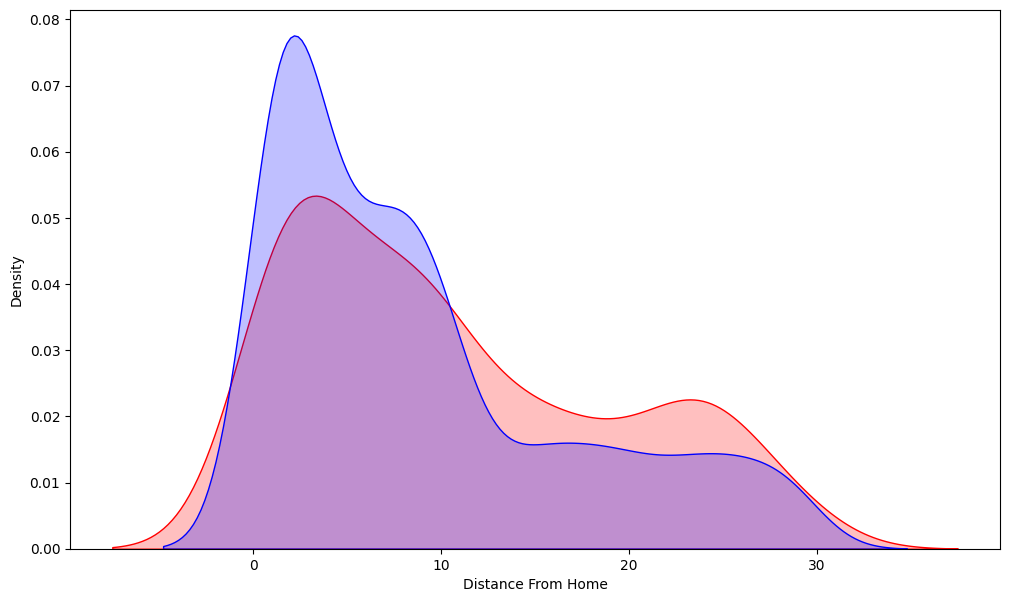

In [53]:
plt.figure(figsize=(12,7))
sns.kdeplot(left_df['Distance From Home'], label='Employees who left', shade=True, color='r')
sns.kdeplot(stayed_df['Distance From Home'], label='Employees who left', shade=True, color='b')
plt.show()

C:\Users\kokki\AppData\Local\Temp\ipykernel_15640\785800930.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(left_df['Total Working Years'], label = 'Employees who left', shade = True, color = 'r')
C:\Users\kokki\AppData\Local\Temp\ipykernel_15640\785800930.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(stayed_df['Total Working Years'], label = 'Employees who Stayed', shade = True, color = 'b')


Text(0.5, 0, 'Years worked in the company')

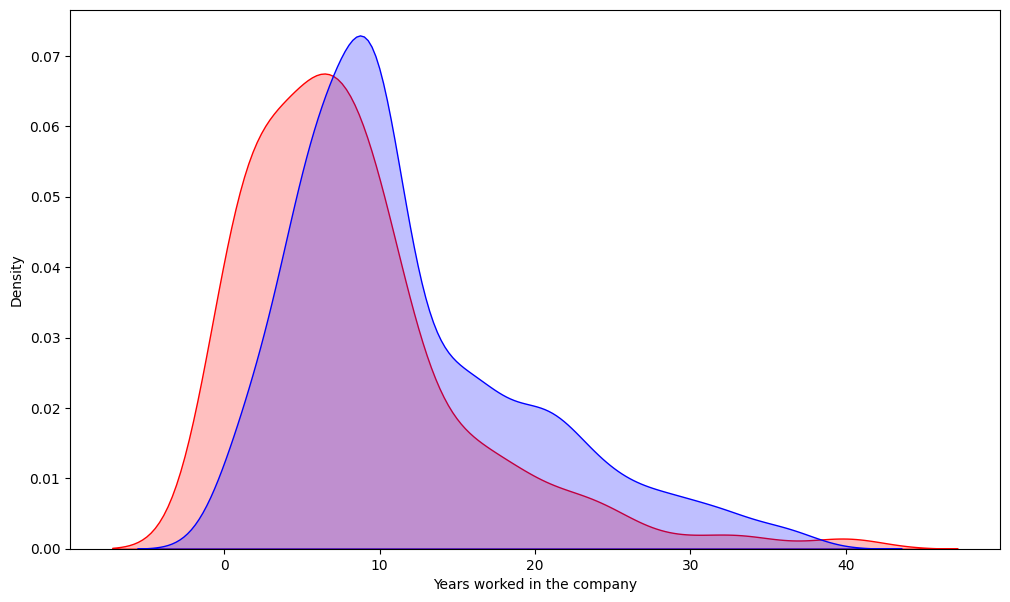

In [55]:
plt.figure(figsize=(12,7))

sns.kdeplot(left_df['Total Working Years'], label = 'Employees who left', shade = True, color = 'r')
sns.kdeplot(stayed_df['Total Working Years'], label = 'Employees who Stayed', shade = True, color = 'b')

plt.xlabel('Years worked in the company')

In [59]:
df = df.drop(['Employee Number', 'emp no', 'Over18', 'Standard Hours'], axis=1, errors='ignore')

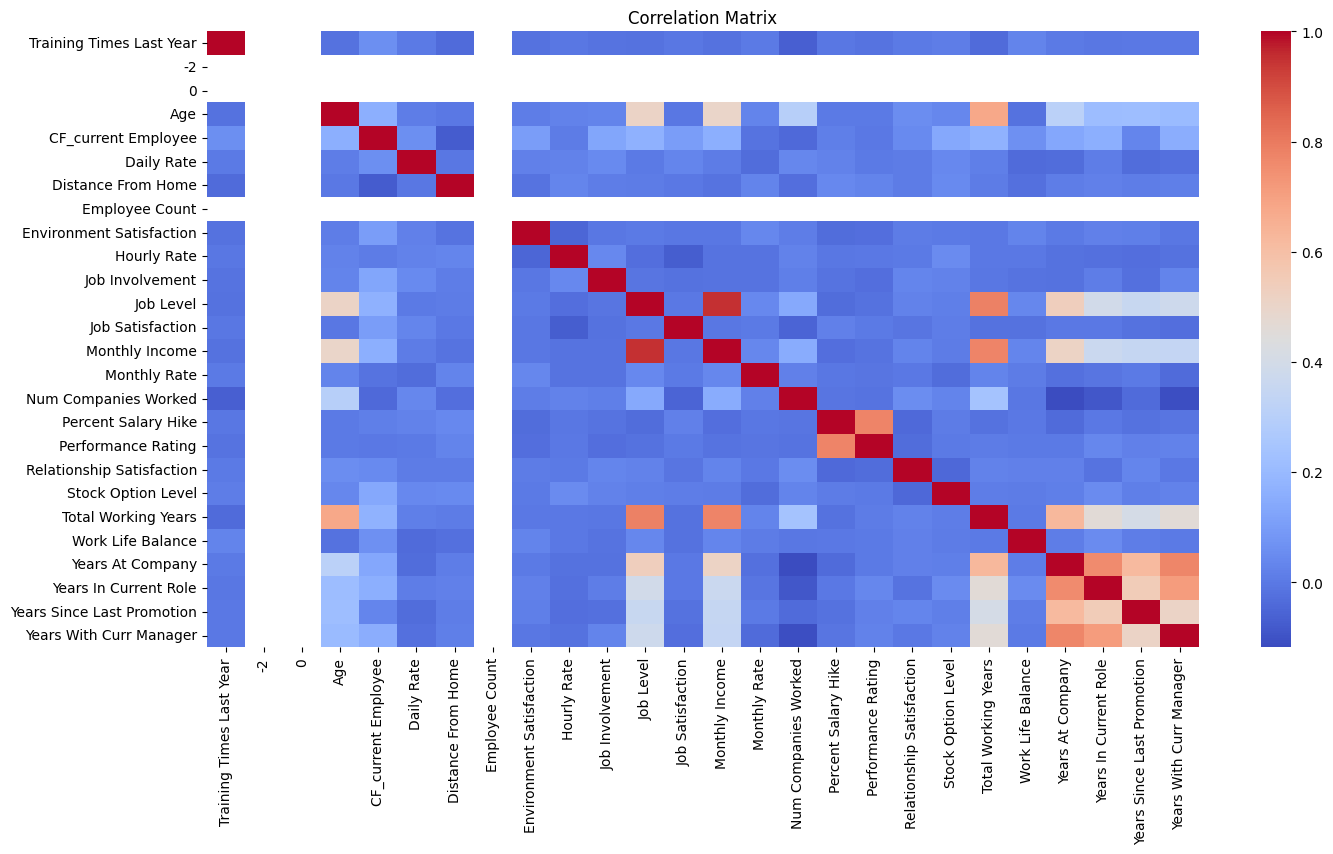

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [106]:
df = df.drop([
    'CF_attrition label',
    'CF_current Employee',
    'Employee Count',
    'Standard Hours',
    'Over18',
    '-2',
    '0'
], axis=1, errors='ignore')

In [107]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns


High-Risk Employees:
    Attrition_Prob  High_Risk
0         0.729379       True
2         0.707256       True
14        0.911030       True
21        0.605883       True
26        0.871850       True

Confusion Matrix:
 [[247   6]
 [ 22  19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       253
           1       0.76      0.46      0.58        41

    accuracy                           0.90       294
   macro avg       0.84      0.72      0.76       294
weighted avg       0.90      0.90      0.89       294



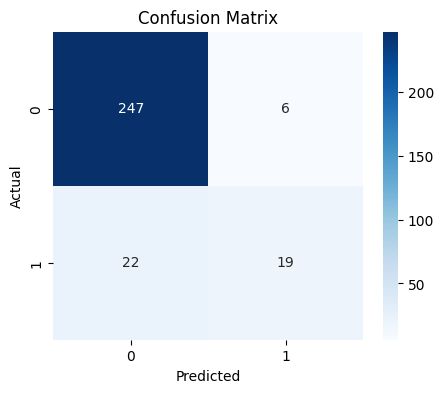


Top Features Influencing Attrition:
                           Feature  Importance
10                 Monthly Income    0.227018
1524                 Over Time_No    0.216865
17            Total Working Years    0.087684
1523        Marital Status_Single    0.081546
3                      Daily Rate    0.060536
20          Years In Current Role    0.051457
1518  Job Role_Research Scientist    0.049275
33               Department_Sales    0.044919
6                     Hourly Rate    0.040831
22        Years With Curr Manager    0.031950


C:\Users\kokki\AppData\Local\Temp\ipykernel_15640\3923570176.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_importance_df.head(10), palette='viridis')


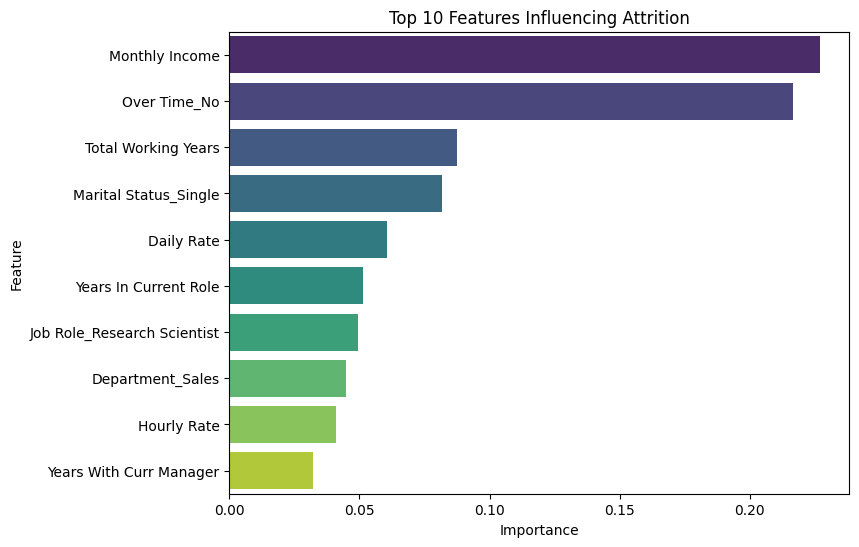

In [117]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns


m_df = pd.read_excel(r"C:\Users\kokki\Downloads\hr.xlsx")
m_df.columns = m_df.columns.str.strip()


m_df['Attrition'] = m_df['Attrition'].astype(str).str.strip().str.lower()
m_df['Attrition'] = m_df['Attrition'].map({'no': 0, 'yes': 1})
m_df = m_df.dropna(subset=['Attrition'])


m_df = m_df.drop([
    'CF_attrition label',
    'CF_current Employee',
    'Employee Count',
    'Standard Hours',
    'Over18',
    '-2',
    '0'
], axis=1, errors='ignore')


X = m_df.drop('Attrition', axis=1)
y = m_df['Attrition']

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()


num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

best_model.fit(X_train, y_train)


m_df['Attrition_Prob'] = best_model.predict_proba(X)[:, 1]


m_df['High_Risk'] = m_df['Attrition_Prob'] > 0.6

print("\nHigh-Risk Employees:")
print(m_df[m_df['High_Risk']][['Attrition_Prob', 'High_Risk']].head())


y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])
dt_model.fit(X, y)


feature_names_num = num_cols
feature_names_cat = dt_model.named_steps['preprocessor'].transformers_[1][1]\
                    .named_steps['encoder'].get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([feature_names_num, feature_names_cat])

importances = dt_model.named_steps['classifier'].feature_importances_


feat_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop Features Influencing Attrition:\n", feat_importance_df.head(10))


plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df.head(10), palette='viridis')
plt.title("Top 10 Features Influencing Attrition")
plt.show()


Attrition Risk Clusters Distribution:
Risk_Cluster_Label
Low       1062
Medium     268
High       140
Name: count, dtype: int64


C:\Users\kokki\AppData\Local\Temp\ipykernel_15640\1239222129.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk_Cluster_Label', data=m_df, order=['Low','Medium','High'], palette='coolwarm')


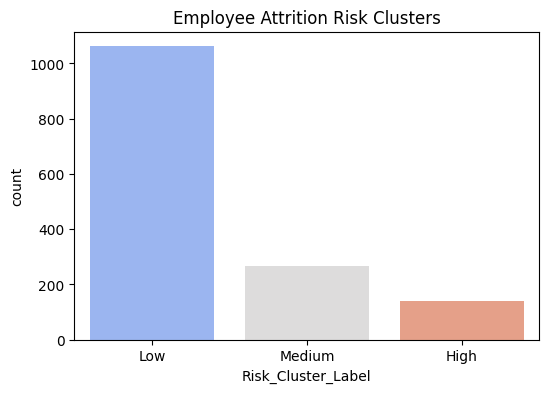

In [118]:
from sklearn.cluster import KMeans



probs = m_df['Attrition_Prob'].values.reshape(-1,1)


kmeans = KMeans(n_clusters=3, random_state=42)
m_df['Risk_Cluster'] = kmeans.fit_predict(probs)


cluster_centers = kmeans.cluster_centers_.flatten()
cluster_order = cluster_centers.argsort()  # ascending order


cluster_mapping = {cluster_order[0]: 'Low', 
                   cluster_order[1]: 'Medium', 
                   cluster_order[2]: 'High'}

m_df['Risk_Cluster_Label'] = m_df['Risk_Cluster'].map(cluster_mapping)


print("\nAttrition Risk Clusters Distribution:")
print(m_df['Risk_Cluster_Label'].value_counts())



plt.figure(figsize=(6,4))
sns.countplot(x='Risk_Cluster_Label', data=m_df, order=['Low','Medium','High'], palette='coolwarm')
plt.title("Employee Attrition Risk Clusters")
plt.show()

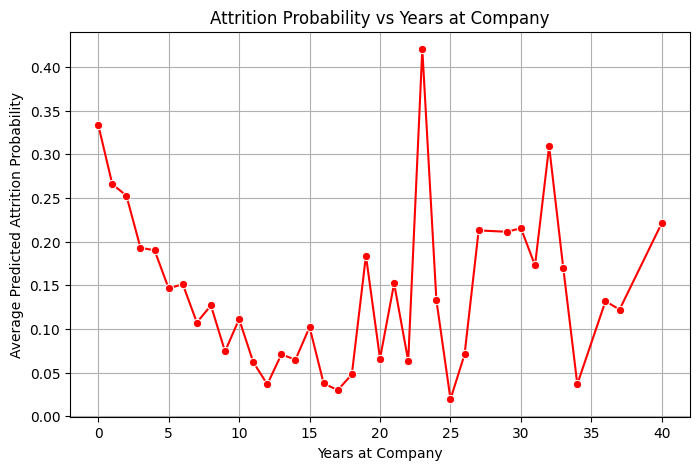

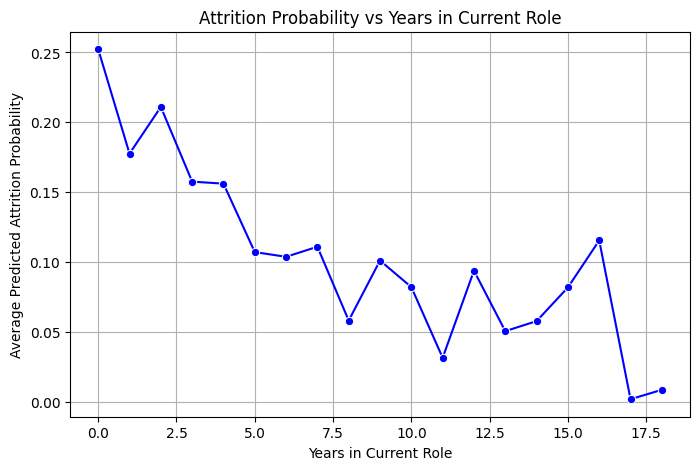

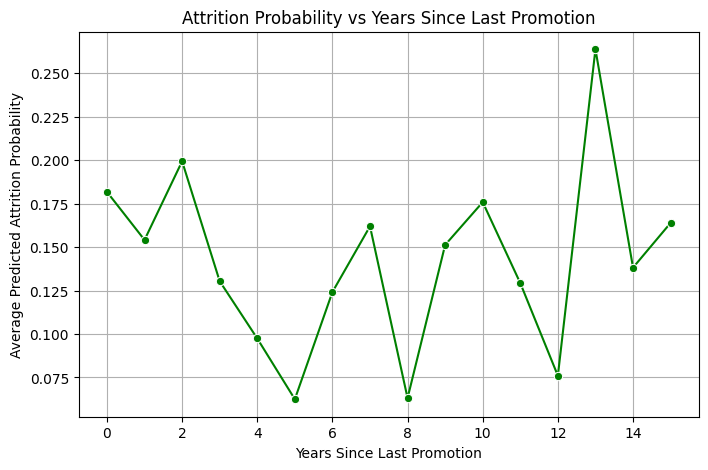

In [119]:

time_cols = ['Years At Company', 'Years In Current Role', 'Years Since Last Promotion', 'Age']
for col in time_cols:
    m_df[col] = pd.to_numeric(m_df[col], errors='coerce')


df_time = m_df.dropna(subset=time_cols + ['Attrition_Prob'])


tenure_analysis = df_time.groupby('Years At Company')['Attrition_Prob'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(x='Years At Company', y='Attrition_Prob', data=tenure_analysis, marker='o', color='red')
plt.title("Attrition Probability vs Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Average Predicted Attrition Probability")
plt.grid(True)
plt.show()


role_analysis = df_time.groupby('Years In Current Role')['Attrition_Prob'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(x='Years In Current Role', y='Attrition_Prob', data=role_analysis, marker='o', color='blue')
plt.title("Attrition Probability vs Years in Current Role")
plt.xlabel("Years in Current Role")
plt.ylabel("Average Predicted Attrition Probability")
plt.grid(True)
plt.show()


promotion_analysis = df_time.groupby('Years Since Last Promotion')['Attrition_Prob'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(x='Years Since Last Promotion', y='Attrition_Prob', data=promotion_analysis, marker='o', color='green')
plt.title("Attrition Probability vs Years Since Last Promotion")
plt.xlabel("Years Since Last Promotion")
plt.ylabel("Average Predicted Attrition Probability")
plt.grid(True)
plt.show()